#  Exploitation de données électorales de la présidentielle de 2022

**Évaluation intermédiaire Python pour la data science (mi-semestre 2026)**  
Auteur : BANZOUZI MIAMPASSI Hermann et TCHATCHOU NJATCHA Neville  
Date : Mars 2026

---

**Objectif :** explorer les données du premier tour de l'élection présidentielle française 2022,
calculer des indicateurs de surreprésentation géographique et les visualiser.

**Source des données :** [data.gouv.fr](https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb)

## Initialisation

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

# Configuration générale de matplotlib
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## Chargement des données

In [18]:
URL_DONNEES = 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'

df = pd.read_csv(URL_DONNEES)

print(f'Données chargées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head(3)

Données chargées : 528,675 lignes × 7 colonnes


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38


---
## 1. Explorations générales

###  Question 1 – Création et mise à jour de variables

In [3]:
# Code commune INSEE (5 caractères)

def build_insee_code(dept, commune):
    """Construit le code INSEE commune (5 caractères).
    
    Parameters
    ----------
    dept : str
        Code département (ex: '01', '2A', '971')
    commune : int
        Numéro de commune local (ex: 49)
    
    Returns
    -------
    str
        Code INSEE à 5 caractères (ex: '92049')
    """
    dept_str = str(dept)
    n_zeros = 5 - len(dept_str)  # 3 pour métropole/Corse, 2 pour DROM
    return dept_str + str(int(commune)).zfill(n_zeros)


df['code_commune'] = df.apply(
    lambda row: build_insee_code(row['code_departement'], row['code_commune']),
    axis=1
)

# Vérification : Montrouge (dép. 92, numéro 49) → '92049'
code_montrouge = df.loc[
    df['libelle_commune'].str.contains('Montrouge', na=False), 'code_commune'
].iloc[0]
assert code_montrouge == '92049', f'Attendu 92049, obtenu {code_montrouge}'
print(f'Code commune de Montrouge : {code_montrouge} ')


# 1b. Colonne candidat (prénom + nom) 
# fillna('') évite d'afficher 'nan' pour les abstentions/blancs/nuls
df['candidat'] = (
    df['prenom'].fillna('').str.strip()
    + ' '
    + df['nom'].str.strip()
).str.strip()

# Aperçu du résultat
df[['code_departement', 'libelle_commune', 'code_commune', 'candidat', 'voix']].head(5)

Code commune de Montrouge : 92049 


,code_departement,libelle_commune,code_commune,candidat,voix
0,01,L'Abergement-Clémenciat,01001,Nathalie ARTHAUD,3
1,01,L'Abergement-de-Varey,01002,Nathalie ARTHAUD,2
2,01,Ambérieu-en-Bugey,01004,Nathalie ARTHAUD,38
3,01,Ambérieux-en-Dombes,01005,Nathalie ARTHAUD,8
4,01,Ambléon,01006,Nathalie ARTHAUD,0


###  Question 2 – Nombre de candidats en 2022

In [4]:
# Les votes non exprimés sont identifiés par leur valeur dans 'nom' (en minuscules dans le CSV)
# On vérifie avec : df['nom'].str.lower().unique()
NON_CANDIDATS = {'abstentions', 'blancs', 'nuls'}

masque_candidats = ~df['nom'].str.lower().isin(NON_CANDIDATS)
df_candidats = df[masque_candidats]

n_candidats = df_candidats['candidat'].nunique()

print(f"En 2022, il y avait {n_candidats} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


### ✏️ Question 3 – Scores nationaux des candidats

Le score est calculé en pourcentage des **votes exprimés** (hors abstentions, blancs et nuls).

In [10]:
# Agrégation : somme des voix par candidat
scores_nationaux = (
    df_candidats
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_national'})
    .sort_values('votes_national', ascending=False)
    .reset_index(drop=True)
)

total_votes_exprimes = scores_nationaux['votes_national'].sum()
scores_nationaux['score_national'] = (
    scores_nationaux['votes_national'] / total_votes_exprimes * 100
)

print(f'Total votes exprimés : {total_votes_exprimes:,}')

scores_nationaux

Total votes exprimés : 35,132,947


,candidat,votes_national,score_national
0,Emmanuel MACRON,9783058,27.845822
1,Marine LE PEN,8133828,23.151568
2,Jean-Luc MÉLENCHON,7712520,21.952386
3,Éric ZEMMOUR,2485226,7.073776
4,Valérie PÉCRESSE,1679001,4.778993
5,Yannick JADOT,1627853,4.633409
6,Jean LASSALLE,1101387,3.134912
7,Fabien ROUSSEL,802422,2.283959
8,Nicolas DUPONT-AIGNAN,725176,2.064091
9,Anne HIDALGO,616478,1.754701


---
## 2. Comparaison des scores départementaux aux moyennes nationales

###  Question 4 – Scores par département

In [11]:
# Voix par (département × candidat)
voix_par_dept = (
    df_candidats
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_departement'})
)

# Total des votes exprimés par département (pour calculer les %)
total_par_dept = (
    voix_par_dept
    .groupby('code_departement')['votes_departement']
    .sum()
    .rename('total_dept')
)

# Score départemental en %
score_departements = (
    voix_par_dept
    .join(total_par_dept, on='code_departement')
    .assign(score_departement=lambda x: x['votes_departement'] / x['total_dept'] * 100)
    .drop(columns='total_dept')
)

# Vérification sur l'Aude (département 11)
print('Vérification pour le département 11 (Aude) :')
(
    score_departements[score_departements['code_departement'] == '11']
    .sort_values('votes_departement', ascending=False)
    .head(5)
    .assign(score_departement=lambda x: x['score_departement'].map('{:.2f}%'.format))
    .reset_index(drop=True)
)

Vérification pour le département 11 (Aude) :


,code_departement,candidat,votes_departement,score_departement
0,11,Marine LE PEN,64027,30.14%
1,11,Emmanuel MACRON,43104,20.29%
2,11,Jean-Luc MÉLENCHON,42039,19.79%
3,11,Éric ZEMMOUR,18434,8.68%
4,11,Jean LASSALLE,12382,5.83%


###  Question 5 – Jointure avec le niveau national

In [12]:
# Fusion des scores départementaux avec les scores nationaux
score_departements = score_departements.merge(
    scores_nationaux[['candidat', 'votes_national', 'score_national']],
    on='candidat',
    how='left'
)

# Vérification sur l'Aude (département 11) – trois premiers candidats
print('Vérification pour le département 11 (Aude) :')
(
    score_departements[score_departements['code_departement'] == '11']
    .sort_values('votes_departement', ascending=False)
    .head(3)
    .reset_index(drop=True)
)

Vérification pour le département 11 (Aude) :


,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,11,Marine LE PEN,64027,30.140849,8133828,23.151568
1,11,Emmanuel MACRON,43104,20.291301,9783058,27.845822
2,11,Jean-Luc MÉLENCHON,42039,19.789950,7712520,21.952386


### ✏️ Question 6 – Variable de surreprésentation

La surreprésentation mesure l'écart **relatif** entre le score départemental et le score national :  
$$\text{surreprésentation} = \frac{\text{score\_dept} - \text{score\_national}}{\text{score\_national}} \times 100$$

Exemple : score département = 30 %, score national = 15 % → surreprésentation = **+100 %**

In [13]:
score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - score_departements['score_national'])
    / score_departements['score_national']
    * 100
)

# Aperçu
score_departements[
    ['code_departement', 'candidat', 'score_departement', 'score_national', 'surrepresentation']
].sort_values('surrepresentation', ascending=False).head(5)

,code_departement,candidat,score_departement,score_national,surrepresentation
1257,986,Valérie PÉCRESSE,25.265908,4.778993,428.686880
771,64,Jean LASSALLE,12.016738,3.134912,283.319766
351,2B,Jean LASSALLE,10.955153,3.134912,249.456460
783,65,Jean LASSALLE,10.943153,3.134912,249.073676
1254,986,Nathalie ARTHAUD,1.828699,0.560995,225.974401


###  Question 7 – Visualisation des surreprésentations par département

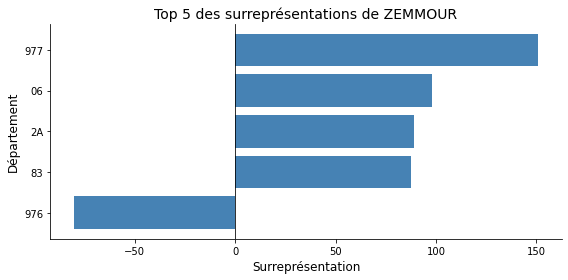

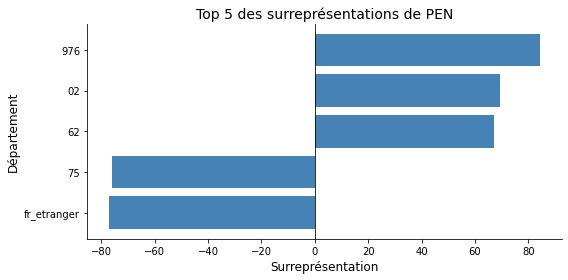

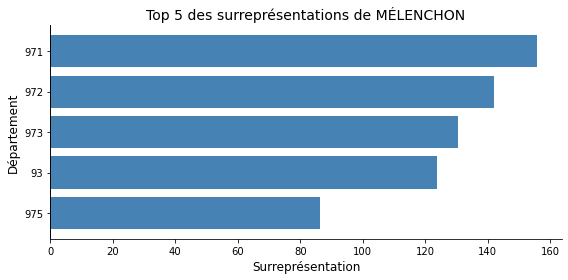

In [14]:
def plot_top_surrepresentation(df, candidat, n=5):
    """Représente les N départements avec les plus grandes surreprésentations
    (en valeur absolue) pour un candidat donné.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant les colonnes 'candidat', 'code_departement',
        'surrepresentation'.
    candidat : str
        Nom complet du candidat (ex: 'Éric ZEMMOUR').
    n : int, optional
        Nombre de départements à afficher (défaut : 5).

    Returns
    -------
    matplotlib.axes.Axes
    """
    # Top N départements en valeur absolue, triés pour affichage
    donnees = (
        df[df['candidat'] == candidat]
        .assign(abs_surr=lambda x: x['surrepresentation'].abs())
        .nlargest(n, 'abs_surr')
        .drop(columns='abs_surr')
        .sort_values('surrepresentation')  # du plus négatif au plus positif
    )

    # ax doit être créé dans la fonction (bug corrigé : ax était utilisé sans être défini)
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.barh(
        donnees['code_departement'],
        donnees['surrepresentation'],
        color='steelblue'
    )
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Surreprésentation')
    ax.set_ylabel('Département')

    nom_famille = candidat.split()[-1]
    ax.set_title(f'Top {n} des surreprésentations de {nom_famille}')

    plt.tight_layout()
    return ax


# Exemples d'utilisation
ax = plot_top_surrepresentation(score_departements, 'Éric ZEMMOUR')
plt.show()

ax = plot_top_surrepresentation(score_departements, 'Marine LE PEN')
plt.show()

ax = plot_top_surrepresentation(score_departements, 'Jean-Luc MÉLENCHON')
plt.show()

---
## 3.  cartographie

###  Question 8 – Carte choroplèthe des surreprésentations

In [15]:
# Téléchargement du fond de carte des départements
from cartiflette import carti_download

departement_borders = carti_download(
    values=['France'],
    crs=4326,
    borders='DEPARTEMENT',
    vectorfile_format='geojson',
    simplification=50,
    filter_by='FRANCE_ENTIERE_DROM_RAPPROCHES',
    source='EXPRESS-COG-CARTO-TERRITOIRE',
    year=2022
)

print(f'Fond de carte chargé : {len(departement_borders)} départements')
print(f'Colonnes disponibles : {departement_borders.columns.tolist()}')

Fond de carte chargé : 105 départements
Colonnes disponibles : ['INSEE_DEP', 'PAYS', 'LIBELLE_DEPARTEMENT', 'POPULATION', 'SOURCE', 'geometry']


Marine LE PEN : 108 départements


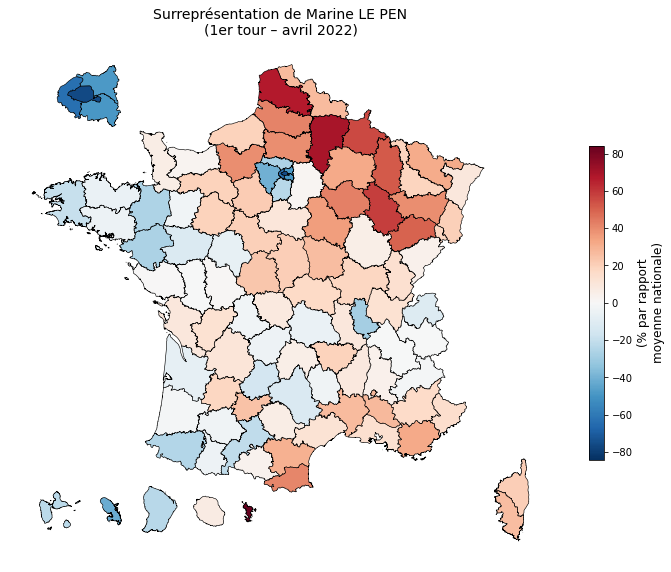

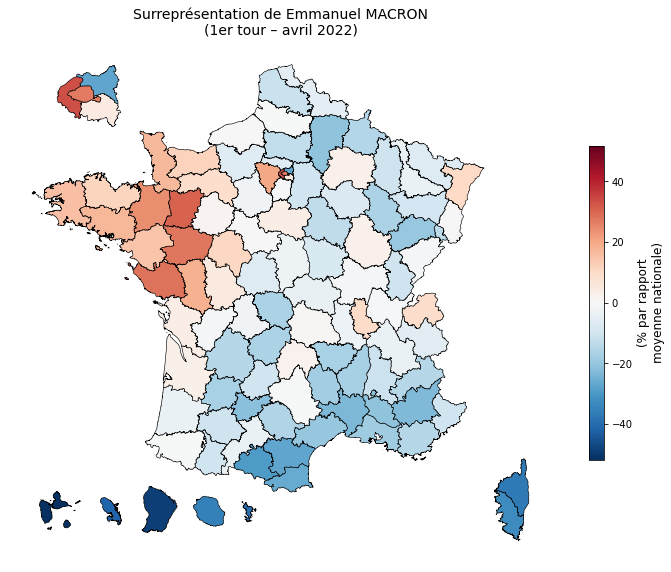

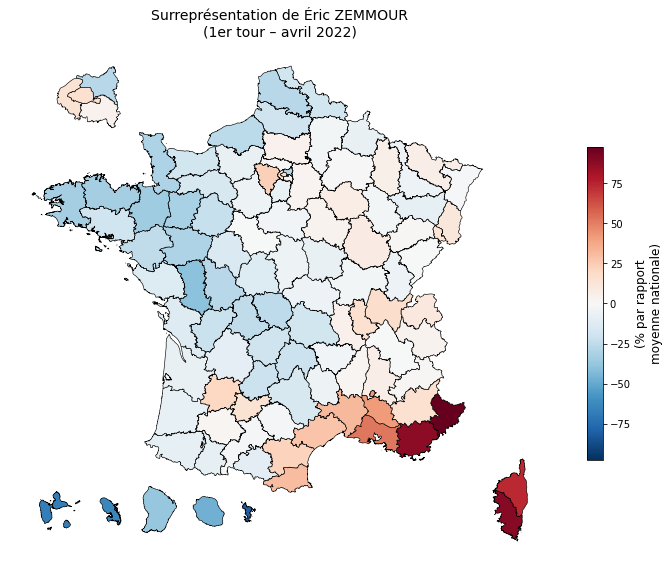

In [16]:
def carte_surrepresentation(df, candidat, departement_borders, col_dept='INSEE_DEP'):
    """Génère une carte choroplèthe de la surreprésentation départementale
    pour un candidat donné.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame score_departements avec les colonnes 'candidat',
        'code_departement', 'surrepresentation'.
    candidat : str
        Nom complet du candidat.
    departement_borders : geopandas.GeoDataFrame
        Fond de carte des départements.
    col_dept : str, optional
        Nom de la colonne département dans le fond de carte (défaut : 'INSEE_DEP').
    
    Returns
    -------
    matplotlib.axes.Axes
    """
    donnees_candidat = (
        df[df['candidat'] == candidat]
        [['code_departement', 'surrepresentation']]
    )

    carte = departement_borders.merge(
        donnees_candidat,
        left_on=col_dept,
        right_on='code_departement',
        how='left'
    )

    # Colormap divergente centrée sur 0 (rouge = surreprésentation, bleu = sous-représentation)
    valeur_max = carte['surrepresentation'].abs().max()

    fig, ax = plt.subplots(figsize=(10, 8))
    carte.plot(
        column='surrepresentation',
        cmap='RdBu_r',
        vmin=-valeur_max,
        vmax=valeur_max,
        legend=True,
        legend_kwds={
            'label': '(% par rapport\nmoyenne nationale)',
            'orientation': 'vertical',
            'shrink': 0.6
        },
        edgecolor='black',
        linewidth=0.6,
        ax=ax
    )

    ax.set_title(f'Surreprésentation de {candidat}\n(1er tour – avril 2022)', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    return ax


#  Restriction du dataframe à un candidat (sans écraser score_departements) ---

def filtrer_candidat(df, candidat):
    """Retourne un sous-ensemble du dataframe filtré sur un candidat."""
    return df[df['candidat'] == candidat].copy()


# Test sur Marine Le Pen
df_le_pen = filtrer_candidat(score_departements, 'Marine LE PEN')
print(f'Marine LE PEN : {len(df_le_pen)} départements')

ax = carte_surrepresentation(score_departements, 'Marine LE PEN', departement_borders)
plt.show()

# Emmanuel Macron
ax = carte_surrepresentation(score_departements, 'Emmanuel MACRON', departement_borders)
plt.show()

# Éric Zemmour
ax = carte_surrepresentation(score_departements, 'Éric ZEMMOUR', departement_borders)
plt.show()

---
##  Synthèse

Ce notebook a permis de :

1. **Nettoyer les données** : construction du code INSEE commune (5 caractères) et création d'une colonne candidat unifiée.
2. **Calculer les scores nationaux** : Marine Le Pen et Emmanuel Macron arrivent en tête avec respectivement 23,15 % et 27,85 % des votes exprimés.
3. **Analyser la territorialité des votes** : la variable de surreprésentation met en évidence des dynamiques géographiques marquées — Marine Le Pen domine dans le nord et le midi méditerranéen, Zemmour sur la Côte d'Azur et la Corse.
4. **Visualiser géographiquement** les écarts à la moyenne nationale par département.
